# Charlotte, North Carolina: Population Growth and Affordable Housing

**DTSC 2301 — Personal Portfolio Project Part One**

**Research question:** *Is Charlotte, North Carolina able to address adequate affordable housing needs in response to population and economic growth?*


## 2. Data Description

The data come from the U.S. Census Bureau's **American Community Survey (ACS) 5-Year Estimates**. ACS provides annual estimates covering social, economic, housing, and demographic characteristics. The 5-year product is useful for a city-level time series because it provides estimates for places such as Charlotte.

| Variable | ACS variable | Operational definition |
|---|---|---|
| Population | `DP05_0001E` | Estimated total population |
| Median household income | `DP03_0062E` | Median household income in the ACS estimate's inflation-adjusted dollars |
| Poverty rate | `DP03_0128PE` | Percent of all people below the poverty level |
| Median rent | `DP04_0134E` | Median gross rent among occupied units paying rent |
| Median home value | `DP04_0089E` | Median value of owner-occupied housing units |
| Housing units | `DP04_0001E` | Total housing units |
| Renter cost burden | `DP04_0141PE + DP04_0142PE` | Percent of renter-occupied units paying 30% or more of household income in gross rent |



In [7]:
# Install/import packages if needed.
# In Jupyter, uncomment the next line if pandas/matplotlib/seaborn are missing.
# %pip install pandas matplotlib seaborn requests

import getpass
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("CENSUS_API_KEY")

print("API key loaded:",API_KEY is not None)
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


API key loaded: True


In [8]:
years = range(2010, 2025)
state = '37'       # North Carolina
place = '12000'    # Charlotte city

variables = [
    'NAME',
    'DP05_0001E',   # population
    'DP03_0062E',   # median household income
    'DP03_0128PE',  # poverty rate
    'DP04_0134E',   # median gross rent
    'DP04_0089E',   # median home value
    'DP04_0001E',   # housing units
    'DP04_0141PE',  # renter cost burden: 30.0-34.9%
    'DP04_0142PE'   # renter cost burden: 35%+
]

def get_acs_year(year):
    url = f'https://api.census.gov/data/{year}/acs/acs5/profile'
    params = {
        'get': ','.join(variables),
        'for': f'place:{place}',
        'in': f'state:{state}',
        'key': API_KEY
    }
    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    data = response.json()
    return pd.DataFrame(data[1:], columns=data[0])

frames = []
for year in years:
    try:
        temp = get_acs_year(year)
        temp['year'] = year
        frames.append(temp)
    except Exception as e:
        print(f'Could not retrieve {year}: {e}')

raw = pd.concat(frames, ignore_index=True)
raw.head()


Could not retrieve 2010: 400 Client Error:  for url: https://api.census.gov/data/2010/acs/acs5/profile?get=NAME%2CDP05_0001E%2CDP03_0062E%2CDP03_0128PE%2CDP04_0134E%2CDP04_0089E%2CDP04_0001E%2CDP04_0141PE%2CDP04_0142PE&for=place%3A12000&in=state%3A37&key=946530dc5baa2fa400cd54ef800078955b50a2db
Could not retrieve 2011: 400 Client Error:  for url: https://api.census.gov/data/2011/acs/acs5/profile?get=NAME%2CDP05_0001E%2CDP03_0062E%2CDP03_0128PE%2CDP04_0134E%2CDP04_0089E%2CDP04_0001E%2CDP04_0141PE%2CDP04_0142PE&for=place%3A12000&in=state%3A37&key=946530dc5baa2fa400cd54ef800078955b50a2db
Could not retrieve 2012: 400 Client Error:  for url: https://api.census.gov/data/2012/acs/acs5/profile?get=NAME%2CDP05_0001E%2CDP03_0062E%2CDP03_0128PE%2CDP04_0134E%2CDP04_0089E%2CDP04_0001E%2CDP04_0141PE%2CDP04_0142PE&for=place%3A12000&in=state%3A37&key=946530dc5baa2fa400cd54ef800078955b50a2db
Could not retrieve 2013: 400 Client Error:  for url: https://api.census.gov/data/2013/acs/acs5/profile?get=NAME%

,NAME,DP05_0001E,DP03_0062E,DP03_0128PE,DP04_0134E,DP04_0089E,DP04_0001E,DP04_0141PE,DP04_0142PE,state,place,year
0,"Charlotte city, North Carolina",792137,53637,16.8,926,172000,333257,8.8,39.9,37,12000,2015
1,"Charlotte city, North Carolina",808834,55599,15.8,966,178000,337375,8.9,38.5,37,12000,2016
2,"Charlotte city, North Carolina",826060,58202,14.9,1018,187300,343222,9.1,38.1,37,12000,2017
3,"Charlotte city, North Carolina",841611,60886,14.0,1086,200500,351143,8.9,38.0,37,12000,2018
4,"Charlotte city, North Carolina",857425,62817,12.8,1135,220300,359379,9.2,37.9,37,12000,2019


In [9]:
df = raw.copy()

numeric_cols = [
    'DP05_0001E', 'DP03_0062E', 'DP03_0128PE', 'DP04_0134E',
    'DP04_0089E', 'DP04_0001E', 'DP04_0141PE', 'DP04_0142PE'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.rename(columns={
    'DP05_0001E': 'population',
    'DP03_0062E': 'median_household_income',
    'DP03_0128PE': 'poverty_rate',
    'DP04_0134E': 'median_rent',
    'DP04_0089E': 'median_home_value',
    'DP04_0001E': 'housing_units',
    'DP04_0141PE': 'renter_burden_30_34_9',
    'DP04_0142PE': 'renter_burden_35_plus'
})

df['renter_cost_burden_pct'] = (
    df['renter_burden_30_34_9'] + df['renter_burden_35_plus']
)

df['housing_units_per_1000_people'] = (
    df['housing_units'] / df['population'] * 1000
)

analysis_cols = [
    'year', 'NAME', 'population', 'median_household_income',
    'poverty_rate', 'median_rent', 'median_home_value',
    'housing_units', 'renter_cost_burden_pct',
    'housing_units_per_1000_people'
]

df = df[analysis_cols].sort_values('year').reset_index(drop=True)

print('Rows and columns:', df.shape)
print('\nMissing values:')
print(df.isna().sum())

df


Rows and columns: (10, 10)

Missing values:
year                             0
NAME                             0
population                       0
median_household_income          0
poverty_rate                     0
median_rent                      0
median_home_value                0
housing_units                    0
renter_cost_burden_pct           0
housing_units_per_1000_people    0
dtype: int64


,year,NAME,population,median_household_income,poverty_rate,median_rent,median_home_value,housing_units,renter_cost_burden_pct,housing_units_per_1000_people
0,2015,"Charlotte city, North Carolina",792137,53637,16.8,926,172000,333257,48.7,420.706267
1,2016,"Charlotte city, North Carolina",808834,55599,15.8,966,178000,337375,47.4,417.112782
2,2017,"Charlotte city, North Carolina",826060,58202,14.9,1018,187300,343222,47.2,415.492821
3,2018,"Charlotte city, North Carolina",841611,60886,14.0,1086,200500,351143,46.9,417.227199
4,2019,"Charlotte city, North Carolina",857425,62817,12.8,1135,220300,359379,47.1,419.137534
5,2020,"Charlotte city, North Carolina",873570,65359,11.9,1185,235000,367252,46.3,420.403631
6,2021,"Charlotte city, North Carolina",864871,68367,11.6,1260,258000,374123,46.9,432.576650
7,2022,"Charlotte city, North Carolina",875045,74070,11.7,1399,312800,383380,48.1,438.126039
8,2023,"Charlotte city, North Carolina",886283,78438,11.7,1504,351500,390835,49.0,440.982169
9,2024,"Charlotte city, North Carolina",903844,82068,11.7,1612,385700,399305,49.8,441.785308


In [10]:
# Check that the final dataset contains one observation per year.
print('Duplicate years:', df['year'].duplicated().sum())
print('Year range:', df['year'].min(), 'to', df['year'].max())
print('\nData types:')
print(df.dtypes)


Duplicate years: 0
Year range: 2015 to 2024

Data types:
year                               int64
NAME                              object
population                         int64
median_household_income            int64
poverty_rate                     float64
median_rent                        int64
median_home_value                  int64
housing_units                      int64
renter_cost_burden_pct           float64
housing_units_per_1000_people    float64
dtype: object


## Exploratory Analysis


1. Did population and housing supply grow at similar rates?
2. Did household income keep pace with rent and home-value growth?
3. Did renter cost burden improve or worsen over time?


In [11]:
def pct_change(first, last):
    return (last - first) / first * 100

start = df.iloc[0]
end = df.iloc[-1]

summary = pd.DataFrame({
    'indicator': [
        'Population', 'Housing units', 'Median household income',
        'Median rent', 'Median home value', 'Poverty rate',
        'Renter cost burden'
    ],
    'start_value': [
        start['population'], start['housing_units'], start['median_household_income'],
        start['median_rent'], start['median_home_value'], start['poverty_rate'],
        start['renter_cost_burden_pct']
    ],
    'end_value': [
        end['population'], end['housing_units'], end['median_household_income'],
        end['median_rent'], end['median_home_value'], end['poverty_rate'],
        end['renter_cost_burden_pct']
    ]
})

summary['percent_change'] = (
    (summary['end_value'] - summary['start_value']) /
    summary['start_value'] * 100
)

summary.round(2)


,indicator,start_value,end_value,percent_change
0,Population,792137.0,903844.0,14.10
1,Housing units,333257.0,399305.0,19.82
2,Median household income,53637.0,82068.0,53.01
3,Median rent,926.0,1612.0,74.08
4,Median home value,172000.0,385700.0,124.24
5,Poverty rate,16.8,11.7,-30.36
6,Renter cost burden,48.7,49.8,2.26


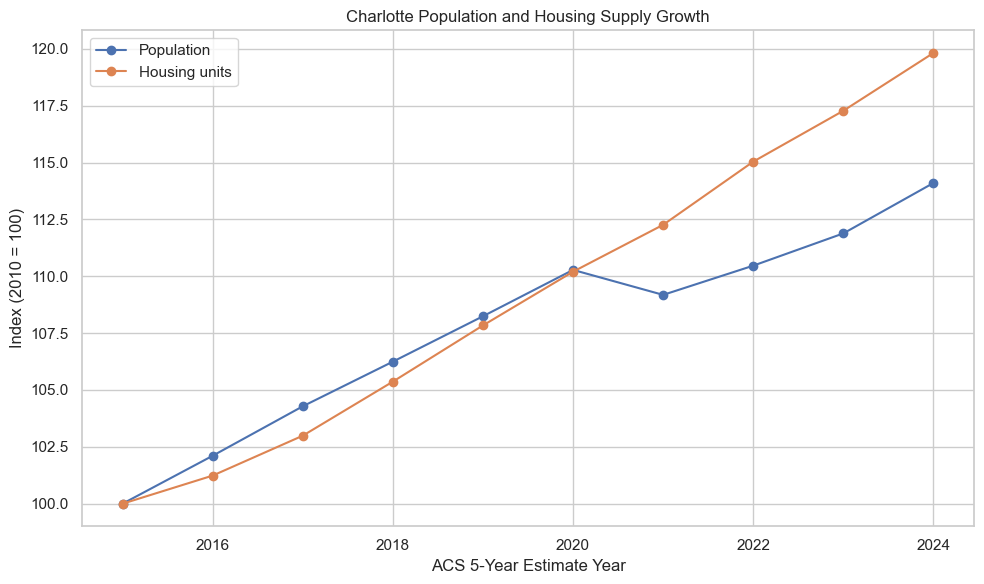

In [12]:
plot_df = df.copy()
plot_df['population_index'] = plot_df['population'] / plot_df['population'].iloc[0] * 100
plot_df['housing_index'] = plot_df['housing_units'] / plot_df['housing_units'].iloc[0] * 100

plt.figure(figsize=(10, 6))
plt.plot(plot_df['year'], plot_df['population_index'], marker='o', label='Population')
plt.plot(plot_df['year'], plot_df['housing_index'], marker='o', label='Housing units')
plt.title('Charlotte Population and Housing Supply Growth')
plt.xlabel('ACS 5-Year Estimate Year')
plt.ylabel('Index (2010 = 100)')
plt.legend()
plt.tight_layout()
plt.show()


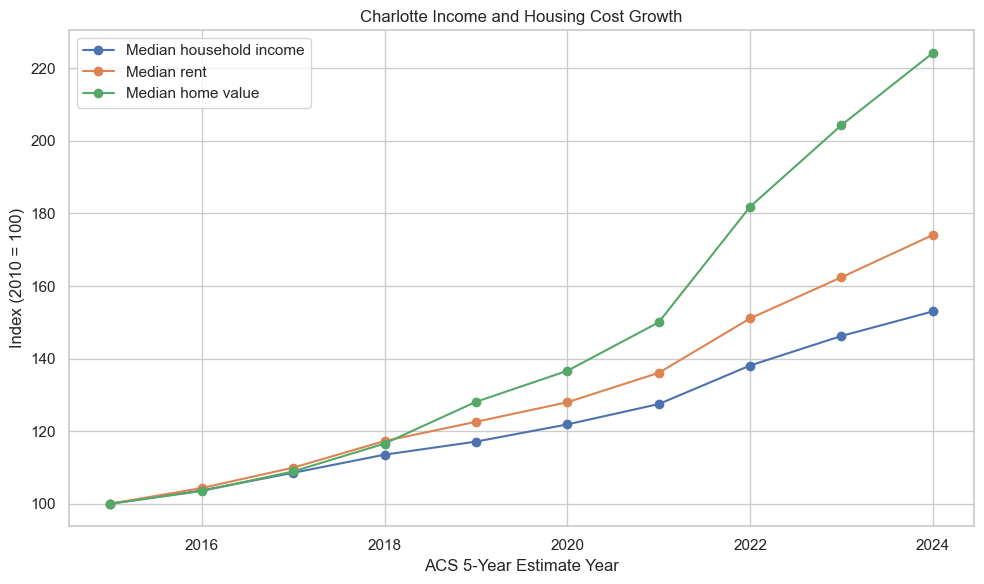

In [13]:
growth_df = pd.DataFrame({
    'year': df['year'],
    'Median household income': df['median_household_income'] / df['median_household_income'].iloc[0] * 100,
    'Median rent': df['median_rent'] / df['median_rent'].iloc[0] * 100,
    'Median home value': df['median_home_value'] / df['median_home_value'].iloc[0] * 100
})

plt.figure(figsize=(10, 6))
for col in growth_df.columns[1:]:
    plt.plot(growth_df['year'], growth_df[col], marker='o', label=col)
plt.title('Charlotte Income and Housing Cost Growth')
plt.xlabel('ACS 5-Year Estimate Year')
plt.ylabel('Index (2010 = 100)')
plt.legend()
plt.tight_layout()
plt.show()


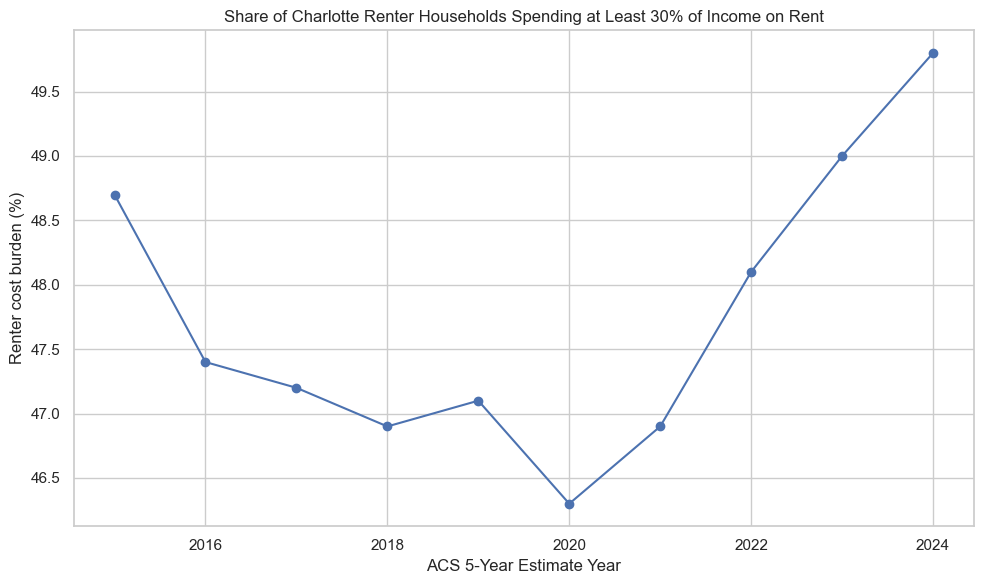

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(df['year'], df['renter_cost_burden_pct'], marker='o')
plt.title('Share of Charlotte Renter Households Spending at Least 30% of Income on Rent')
plt.xlabel('ACS 5-Year Estimate Year')
plt.ylabel('Renter cost burden (%)')
plt.tight_layout()
plt.show()


## Code and AI Transparency

**Data source:** U.S. Census Bureau, American Community Survey 5-Year Estimates, accessed through the Census Data API.

**AI disclosure:** Generative AI (ChatGPT, GPT-5.6 Luna) was used as a coding and writing assistant to help structure the beginner-level Python notebook, explain Census variables, draft documentation, and identify potential limitations. The student should review, run, test, and understand every line of code before submission and disclose AI use according to the course policy.

